**Hypothesis tests and z-scores**

In [4]:
import pandas as pd
import numpy as np

In [3]:
late_shipments = pd.read_feather('data/late_shipments.feather')
late_shipments.head()

,id,country,managed_by,fulfill_via,vendor_inco_term,shipment_mode,late_delivery,late,product_group,sub_classification,...,line_item_quantity,line_item_value,pack_price,unit_price,manufacturing_site,first_line_designation,weight_kilograms,freight_cost_usd,freight_cost_groups,line_item_insurance_usd
0,36203.0,Nigeria,PMO - US,Direct Drop,EXW,Air,1.0,Yes,HRDT,HIV test,...,2996.0,266644.00,89.00,0.89,"Alere Medical Co., Ltd.",Yes,1426.0,33279.83,expensive,373.83
1,30998.0,Botswana,PMO - US,Direct Drop,EXW,Air,0.0,No,HRDT,HIV test,...,25.0,800.00,32.00,1.60,"Trinity Biotech, Plc",Yes,10.0,559.89,reasonable,1.72
2,69871.0,Vietnam,PMO - US,Direct Drop,EXW,Air,0.0,No,ARV,Adult,...,22925.0,110040.00,4.80,0.08,Hetero Unit III Hyderabad IN,Yes,3723.0,19056.13,expensive,181.57
3,17648.0,South Africa,PMO - US,Direct Drop,DDP,Ocean,0.0,No,ARV,Adult,...,152535.0,361507.95,2.37,0.04,"Aurobindo Unit III, India",Yes,7698.0,11372.23,expensive,779.41
4,5647.0,Uganda,PMO - US,Direct Drop,EXW,Air,0.0,No,HRDT,HIV test - Ancillary,...,850.0,8.50,0.01,0.00,Inverness Japan,Yes,56.0,360.00,reasonable,0.01


**Calculating the sample mean**

In [6]:
late_prop_samp = np.mean(late_shipments['late'] == "Yes")
print(f"Proportion of late shipments in sample: {late_prop_samp:.4f}")

Proportion of late shipments in sample: 0.0610


**Calculating a z-score**


In [7]:
late_prop_hyp = 0.06

In [8]:
late_shipments_boot_distn = []
for i in range(10000):
    df = late_shipments.sample(frac=1, replace=True)
    late_shipments_boot_distn.append(
        np.mean(df['late'] == "Yes")
    )

In [10]:
std_error = np.std(late_shipments_boot_distn, ddof=1)
print(f"Standard error of the proportion: {std_error:.4f}")

Standard error of the proportion: 0.0076


In [11]:
z_score = (late_prop_samp - late_prop_hyp) / std_error
print(f"Z-score: {z_score:.4f}")

Z-score: 0.1323


**Calculating p-values**

In [13]:
from scipy.stats import norm
p_value = 1 - norm.cdf(z_score, loc=0, scale=1)
print(f"P-value: {p_value:.4f}")

P-value: 0.4474


**Statistical Significance**

**Calculating a confidence interval**

In [14]:
lower = np.quantile(late_shipments_boot_distn, 0.025)
upper = np.quantile(late_shipments_boot_distn, 0.975)
print(f"95% Confidence Interval: ({lower:.4f}, {upper:.4f})")

95% Confidence Interval: (0.0470, 0.0770)


**Performing t-tests**

**Paired t-test**

In [35]:
sample_dem_data = pd.read_feather('data/dem_votes_potus_12_16.feather')
sample_dem_data.head()

,state,county,dem_percent_12,dem_percent_16
0,Alabama,Bullock,76.305900,74.946921
1,Alabama,Chilton,19.453671,15.847352
2,Alabama,Clay,26.673672,18.674517
3,Alabama,Cullman,14.661752,10.028252
4,Alabama,Escambia,36.915731,31.020546


In [36]:
sample_dem_data['diff'] = sample_dem_data['dem_percent_12'] - sample_dem_data['dem_percent_16']
sample_dem_data.head()

,state,county,dem_percent_12,dem_percent_16,diff
0,Alabama,Bullock,76.305900,74.946921,1.358979
1,Alabama,Chilton,19.453671,15.847352,3.606319
2,Alabama,Clay,26.673672,18.674517,7.999155
3,Alabama,Cullman,14.661752,10.028252,4.633500
4,Alabama,Escambia,36.915731,31.020546,5.895185


In [38]:
xbar_diff = np.mean(sample_dem_data['diff'])
print(f"Mean difference in proportions: {xbar_diff:.4f}")

Mean difference in proportions: 6.8293


In [39]:
s_diff = np.std(sample_dem_data['diff'], ddof=1)
print(f"Standard deviation of differences: {s_diff:.4f}")

Standard deviation of differences: 5.0401


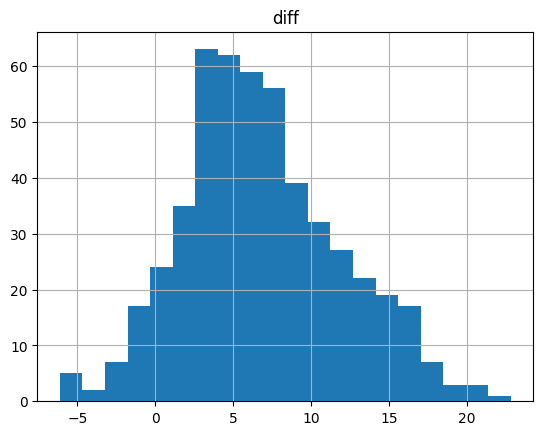

In [41]:
import matplotlib.pyplot as plt
sample_dem_data.hist(column='diff', bins=20)
plt.show()

In [42]:
t_stat = xbar_diff/np.sqrt(s_diff**2/len(sample_dem_data))
print(f"T-statistic: {t_stat:.4f}")

T-statistic: 30.2984


**Using ttest**

In [45]:
from pingouin import ttest

In [138]:
test_results = ttest(
    x=sample_dem_data['diff'],
    y=0,
    alternative='two-sided'
)
print(test_results)

                T  dof alternative          p-val         CI95%   cohen-d  \
T-test  30.298384  499   two-sided  3.600634e-115  [6.39, 7.27]  1.354985   

              BF10 power  
T-test  2.246e+111   NaN  


In [ ]:
test_results = ttest(
    x=sample_dem_data['dem_percent_12'],
    y=sample_dem_data['dem_percent_16'],
    paired=True,
    alternative='two-sided'
)
print(test_results)


                T  dof alternative          p-val         CI95%   cohen-d  \
T-test  30.298384  499   two-sided  3.600634e-115  [6.39, 7.27]  0.454202   

              BF10 power  
T-test  2.246e+111   NaN  


AttributeError: module 'pingouin' has no attribute 'kolmogorov_smirnov'

In [48]:
test_results = ttest(
    x=sample_dem_data['dem_percent_12'],
    y=sample_dem_data['dem_percent_16'],
    paired=False,
    alternative='two-sided'
)
print(test_results)

               T  dof alternative         p-val        CI95%   cohen-d  \
T-test  7.181565  998   two-sided  1.345737e-12  [4.96, 8.7]  0.454202   

             BF10  power  
T-test  4.308e+09    1.0  


**ANOVA tests**

In [51]:
xbar_pack_price = late_shipments.groupby('shipment_mode')['pack_price'].mean()
print(xbar_pack_price)

shipment_mode
Air            39.712395
Air Charter     4.226667
Ocean           6.432273
Name: pack_price, dtype: float64


In [52]:
s_pack_price = late_shipments.groupby('shipment_mode')['pack_price'].std(ddof=1)
print(s_pack_price)

shipment_mode
Air            48.932861
Air Charter     0.992969
Ocean           5.303047
Name: pack_price, dtype: float64


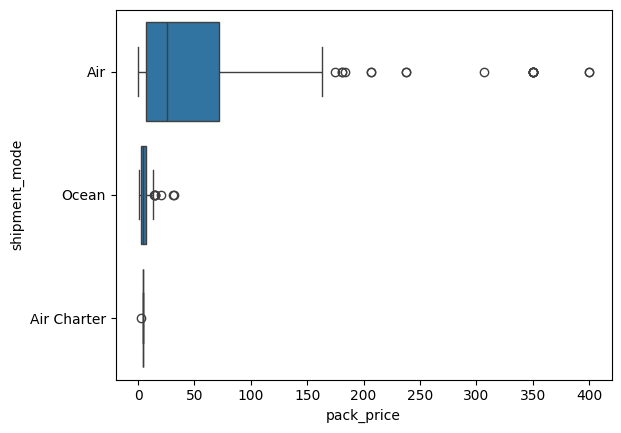

In [56]:
import seaborn as sns
sns.boxplot(
    x='pack_price',
    y='shipment_mode',
    data=late_shipments
)
plt.show()

In [57]:
import pingouin

In [58]:
anova_result = pingouin.anova(
    data=late_shipments,
    dv='pack_price',
    between='shipment_mode'
)
print(anova_result)

          Source  ddof1  ddof2        F         p-unc       np2
0  shipment_mode      2    997  21.8646  5.089479e-10  0.042018


**Pairwise t-test**

In [62]:
pairwise_results = pingouin.pairwise_tests(
    data=late_shipments,
    dv='pack_price',
    between='shipment_mode',
    padjust='none'
)
print(pairwise_results)

        Contrast            A            B  Paired  Parametric          T  \
0  shipment_mode          Air  Air Charter   False        True  21.179625   
1  shipment_mode          Air        Ocean   False        True  19.335760   
2  shipment_mode  Air Charter        Ocean   False        True  -3.170654   

          dof alternative         p-unc       BF10    hedges  
0  600.685682   two-sided  8.748346e-75  5.809e+76  0.726592  
1  986.979785   two-sided  6.934555e-71  1.129e+67  0.711119  
2   35.615026   two-sided  3.123012e-03     15.277 -0.423775  


In [64]:
pairwise_results = pingouin.pairwise_tests(
    data=late_shipments,
    dv='pack_price',
    between='shipment_mode',
    padjust='bonf'
)
print(pairwise_results)

        Contrast            A            B  Paired  Parametric          T  \
0  shipment_mode          Air  Air Charter   False        True  21.179625   
1  shipment_mode          Air        Ocean   False        True  19.335760   
2  shipment_mode  Air Charter        Ocean   False        True  -3.170654   

          dof alternative         p-unc        p-corr p-adjust       BF10  \
0  600.685682   two-sided  8.748346e-75  2.624504e-74     bonf  5.809e+76   
1  986.979785   two-sided  6.934555e-71  2.080367e-70     bonf  1.129e+67   
2   35.615026   two-sided  3.123012e-03  9.369037e-03     bonf     15.277   

     hedges  
0  0.726592  
1  0.711119  
2 -0.423775  


**One-sample proportion tests**

In [65]:
p_0 = 0.06
p_hat =(late_shipments['late'] == "Yes").mean()
n = len(late_shipments)
print(p_hat, n)


0.061 1000


In [66]:
numerator = p_hat - p_0
denominator = np.sqrt(p_0 * (1 - p_0) / n)
z_score = numerator / denominator
print(f"Z-score: {z_score:.4f}")

Z-score: 0.1332


In [67]:
p_value = 1 - norm.cdf(z_score, loc=0, scale=1)
print(f"P-value: {p_value:.4f}")

P-value: 0.4470


**Two-sample proportion tests**

In [71]:
p_hats = late_shipments.groupby('freight_cost_groups')['late'].value_counts(normalize=True)
print(p_hats)

freight_cost_groups  late
expensive            No      0.920904
                     Yes     0.079096
reasonable           No      0.964835
                     Yes     0.035165
Name: proportion, dtype: float64


In [72]:
n=late_shipments.groupby('freight_cost_groups')['late'].count()
print(n)

freight_cost_groups
expensive     531
reasonable    455
Name: late, dtype: int64


In [74]:
p_expensive_yes = p_hats[('expensive', 'Yes')]
p_reasonable_yes = p_hats[('reasonable', 'Yes')]
print(p_expensive_yes, p_reasonable_yes)

0.07909604519774012 0.035164835164835165


In [75]:
n_expensive = n['expensive']
n_reasonable = n['reasonable']  
print(n_expensive, n_reasonable)

531 455


In [ ]:
p_hat = (n_expensive*p_expensive_yes + n_reasonable*p_reasonable_yes)/(n_expensive + n_reasonable)
print(f"Pooled proportion: {p_hat:.4f}")

Pooled proportion: 0.0588


In [78]:
p_hat_times_not_p_hat  = p_hat * (1 - p_hat)
print(f"p_hat * (1 - p_hat): {p_hat_times_not_p_hat}")

p_hat * (1 - p_hat): 0.05536332179930796


In [80]:
p_hat_times_not_p_hat_over_ns = p_hat_times_not_p_hat * (1/n_expensive + 1/n_reasonable)
std_error = np.sqrt(p_hat_times_not_p_hat_over_ns)
z_score = (p_expensive_yes - p_reasonable_yes) / std_error
print(f"Z-score: {z_score:.4f}")

Z-score: 2.9226


In [81]:
p_value = 1 - norm.cdf(z_score, loc=0, scale=1)
print(f"P-value: {p_value:.4f}")

P-value: 0.0017


**proportions_ztest() for two samples**

In [83]:
late_by_freight_cost_group = late_shipments.groupby('freight_cost_groups')['late'].value_counts()
print(late_by_freight_cost_group)

freight_cost_groups  late
expensive            No      489
                     Yes      42
reasonable           No      439
                     Yes      16
Name: count, dtype: int64


In [85]:
success_counts = np.array([42, 16])
n = np.array([489+42, 439+16])

In [86]:
from statsmodels.stats.proportion import proportions_ztest
stat, p_value = proportions_ztest(
    count=success_counts,
    nobs=n,
    alternative='larger'
)
print(stat, p_value)

2.922648567784529 0.001735340002359578


**Chi-square test of independence**

In [90]:
props = late_shipments.groupby('vendor_inco_term')['freight_cost_groups'].value_counts(normalize=True)
print(props)

vendor_inco_term  freight_cost_groups
CIP               reasonable             0.680000
                  expensive              0.320000
DDP               expensive              0.550000
                  reasonable             0.450000
DDU               reasonable             1.000000
EXW               expensive              0.583448
                  reasonable             0.416552
FCA               reasonable             0.663636
                  expensive              0.336364
Name: proportion, dtype: float64


In [91]:
wide_props = props.unstack()
print(wide_props)

freight_cost_groups  expensive  reasonable
vendor_inco_term                          
CIP                   0.320000    0.680000
DDP                   0.550000    0.450000
DDU                        NaN    1.000000
EXW                   0.583448    0.416552
FCA                   0.336364    0.663636


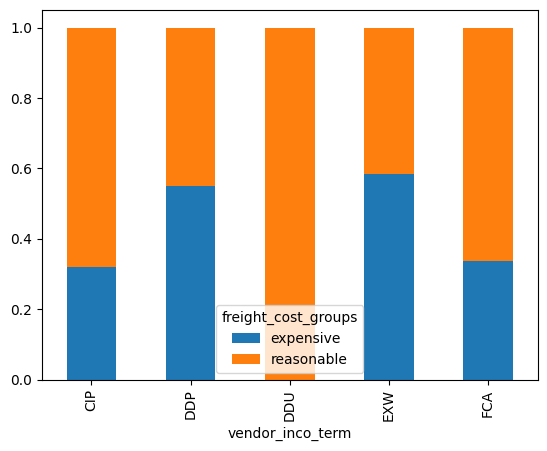

In [93]:
wide_props.plot(kind='bar', stacked=True)
plt.show()

In [97]:
expected, observed, stats = pingouin.chi2_independence(
    data=late_shipments,
    x='vendor_inco_term',
    y='freight_cost_groups'
)
print(stats)

                 test    lambda       chi2  dof          pval    cramer  \
0             pearson  1.000000  34.805072  4.0  5.093922e-07  0.186561   
1        cressie-read  0.666667  34.845134  4.0  4.998337e-07  0.186669   
2      log-likelihood  0.000000  35.442911  4.0  3.767119e-07  0.188263   
3       freeman-tukey -0.500000        NaN  4.0           NaN       NaN   
4  mod-log-likelihood -1.000000        inf  4.0  0.000000e+00       inf   
5              neyman -2.000000        NaN  4.0           NaN       NaN   

      power  
0  0.999235  
1  0.999244  
2  0.999361  
3       NaN  
4       NaN  
5       NaN  


C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\pingouin\contingency.py:151: UserWarning: Low count on observed frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\pingouin\contingency.py:151: UserWarning: Low count on expected frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
c:\ProgramData\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:7344: RuntimeWarning: divide by zero encountered in power
  terms = f_obs * ((f_obs / f_exp)**lambda_ - 1)
c:\ProgramData\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:7344: RuntimeWarning: invalid value encountered in multiply
  terms = f_obs * ((f_obs / f_exp)**lambda_ - 1)
c:\ProgramData\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:7341: RuntimeWarning: divide by zero encountered in divide
  terms = 2.0 * special.xlogy(f_exp, f_exp / f_obs)


In [99]:
print(stats[stats['test'] == 'pearson'])

      test  lambda       chi2  dof          pval    cramer     power
0  pearson     1.0  34.805072  4.0  5.093922e-07  0.186561  0.999235


**Chi-square goodness of fit tests**

In [100]:
n_total = len(late_shipments)
print(n_total)

1000


In [106]:
hypothesized = pd.DataFrame({
    'vendor_inco_term': ['CIP', 'DDP', 'EXW', 'FCA'],
    'prop': [0.05, 0.10, 0.75, 0.10]
})
hypothesized

,vendor_inco_term,prop
0,CIP,0.05
1,DDP,0.10
2,EXW,0.75
3,FCA,0.10


In [107]:
hypothesized['n'] = hypothesized['prop'] * n_total
hypothesized

,vendor_inco_term,prop,n
0,CIP,0.05,50.0
1,DDP,0.10,100.0
2,EXW,0.75,750.0
3,FCA,0.10,100.0


In [117]:
incoterm_counts = pd.DataFrame({
    'vendor_inco_term': ['CIP', 'DDP', 'EXW', 'FCA'],
    'n': [56, 100, 732, 112]
})
incoterm_counts

,vendor_inco_term,n
0,CIP,56
1,DDP,100
2,EXW,732
3,FCA,112


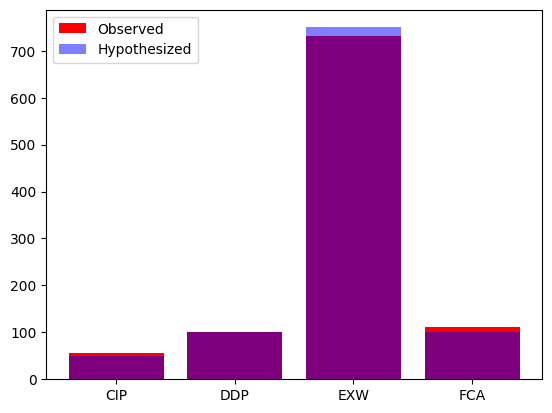

In [118]:
plt.bar(
    incoterm_counts['vendor_inco_term'],
    incoterm_counts['n'],
    color='red',
    label='Observed'
)
plt.bar(
    hypothesized['vendor_inco_term'],
    hypothesized['n'],
    color='blue',
    alpha=0.5,
    label='Hypothesized'
)
plt.legend()
plt.show()

In [119]:
from scipy.stats import chisquare
gof_test = chisquare(
    f_obs=incoterm_counts['n'],
    f_exp=hypothesized['n']
)
print(gof_test)

Power_divergenceResult(statistic=np.float64(2.5919999999999996), pvalue=np.float64(0.4588937766706067))


**Assumptions in hypothesis testing**

***Testing sample size***

In [120]:
counts = late_shipments['freight_cost_groups'].value_counts()
print(counts)

freight_cost_groups
expensive     531
reasonable    455
Name: count, dtype: int64


In [ ]:
print((counts >= 30).all()) 

True


In [122]:
counts =  late_shipments.groupby('vendor_inco_term')['freight_cost_groups'].value_counts()
print(counts)

vendor_inco_term  freight_cost_groups
CIP               reasonable              34
                  expensive               16
DDP               expensive               55
                  reasonable              45
DDU               reasonable               1
EXW               expensive              423
                  reasonable             302
FCA               reasonable              73
                  expensive               37
Name: count, dtype: int64


In [126]:
print((counts >= 5).all())

True


In [124]:
counts = late_shipments['late'].value_counts()
print(counts)

late
No     939
Yes     61
Name: count, dtype: int64


In [125]:
print((counts >= 10).all())

True


In [127]:
counts = late_shipments['shipment_mode'].value_counts()
print(counts)

shipment_mode
Air            906
Ocean           88
Air Charter      6
Name: count, dtype: int64


In [128]:
print((counts >= 30).all()) 

False


**Non-parametric test**

In [129]:
paired_test_results = pingouin.ttest(
    sample_dem_data['dem_percent_12'],
    sample_dem_data['dem_percent_16'],
    paired=True,
    alternative='two-sided'
)
print(paired_test_results)

                T  dof alternative          p-val         CI95%   cohen-d  \
T-test  30.298384  499   two-sided  3.600634e-115  [6.39, 7.27]  0.454202   

              BF10 power  
T-test  2.246e+111   NaN  


In [130]:
wilcoxon_test_results = pingouin.wilcoxon(
    sample_dem_data['dem_percent_12'],
    sample_dem_data['dem_percent_16'],
    alternative='two-sided'
)
print(wilcoxon_test_results)

           W-val alternative         p-val       RBC      CLES
Wilcoxon  2401.0   two-sided  1.780396e-77  0.961661  0.644816


**Non-parametric ANOVA and unpaired t-tests**

In [134]:
weight_vs_late = late_shipments[['weight_kilograms', 'late']]
weight_vs_late_wide = weight_vs_late.pivot(
    columns='late',
    values='weight_kilograms'   
)
print(weight_vs_late_wide.head())

late      No     Yes
0        NaN  1426.0
1       10.0     NaN
2     3723.0     NaN
3     7698.0     NaN
4       56.0     NaN


In [136]:
wmw_test = pingouin.mwu(
    x=weight_vs_late_wide['Yes'],
    y=weight_vs_late_wide['No'],
    alternative='two-sided'
)
print(wmw_test)

       U-val alternative     p-val       RBC      CLES
MWU  38145.0   two-sided  0.000014  0.331902  0.665951


In [137]:
kw_test = pingouin.kruskal(
    data=late_shipments,
    dv='weight_kilograms',
    between='shipment_mode'
)
print(kw_test)

                Source  ddof1           H         p-unc
Kruskal  shipment_mode      2  125.096618  6.848799e-28
